# Generator-Critic - LangChain LCEL

> "The model critiques; the harness decides."

This notebook implements Generator-Critic with **LangChain Expression Language (LCEL)**. The [LangGraph version](../langgraph/tutorial.ipynb) makes each node and route explicit; this version compresses the same pattern into composable runnables.

## What this pattern does

Generator-Critic is a one-pass reflection chain: generate an artifact, critique it, and let deterministic code decide whether it can pass.

| | `langgraph/` (StateGraph) | `langchain/` (LCEL) |
|---|---|---|
| **Mechanism** | Explicit nodes and conditional edge | `prompt | model | parser`, then a runnable gate |
| **Visibility** | More code, all routes visible | Less code, flow is implicit |
| **Shared pieces** | Same parser, policy, mock JSON, reviser | Same `shared.py` pieces |
| **Boundary** | Revision draft ends the pass | Same: revision draft is not auto-accepted |

## Setup

The mock runs are deterministic and need no API key. The real-backend cell at the end uses the root `.env` through [`model_config.py`](../../../model_config.py) and only calls a live model when `run_real_llm` is true.

In [1]:
from __future__ import annotations

# ruff: noqa: E402

import sys
from pathlib import Path

# Notebooks may run from the repo root, this folder, nbmake, or nbconvert.
# Add the directory that owns each marker file so root helpers and local shared
# pattern files resolve without installing the repository as a package.
for _marker in ("shared.py", "model_config.py", "nbtools.py"):
    _dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / _marker).exists())
    sys.path.insert(0, str(_dir))

from langchain_core.language_models.fake_chat_models import FakeListChatModel
from langchain_core.messages import SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

from model_config import get_model, run_real_llm_enabled
from nbtools import show_graph
from pattern import Artifact, ChainResult, Decision
from shared import (
    BAD_CRITIQUE_JSON,
    CRITIC_SYSTEM_PROMPT,
    DEFAULT_PROMPT,
    GOOD_CRITIQUE_JSON,
    INITIAL_DRAFT,
    NEEDS_REVISION_CRITIQUE_JSON,
    default_policy,
    parse_critique_json,
    print_trace,
    revise_with_evidence,
)


## The generator and critic as LCEL chains

Each role is a pipe. The generator returns an `Artifact`; the critic returns a parsed `Critique`. The parser comes from `shared.py`, so malformed critic JSON becomes a blocker critique just like it does in the graph notebook.

In [2]:
def build_generator(model):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Draft a concise customer-facing incident update."),
        ("human", "{prompt}"),
    ])
    # The core pattern receives an Artifact, not a LangChain AIMessage. Keeping
    # that boundary explicit makes the LCEL notebook line up with pattern.py.
    return prompt | model | StrOutputParser() | RunnableLambda(lambda text: Artifact(content=text))


def build_critic(model):
    prompt = ChatPromptTemplate.from_messages([
        # Use a concrete SystemMessage so the JSON schema braces in the shared
        # prompt are not parsed as LCEL template variables.
        SystemMessage(content=CRITIC_SYSTEM_PROMPT),
        ("human", "Artifact:\n{artifact_content}"),
    ])
    return (
        # The critic only sees the generated artifact text. It cannot approve;
        # it can only emit evidence that parse_critique_json turns into Critique.
        RunnableLambda(lambda state: {"artifact_content": state["artifact"].content})
        | prompt
        | model
        | StrOutputParser()
        | RunnableLambda(parse_critique_json)
    )


## The policy gate as a Runnable

The gate turns `{artifact, critique}` into a `ChainResult`. If revision is needed and a reviser is provided, it drafts a revised artifact, but the decision remains `NEEDS_REVISION`. LCEL gives us less routing code than LangGraph, but the safety boundary is identical.

In [3]:
def make_policy_gate(*, policy=None, reviser=None) -> RunnableLambda:
    policy = policy or default_policy()

    def gate(state: dict) -> ChainResult:
        artifact = state["artifact"]
        critique = state["critique"]
        trace = ["generated", "critiqued"]
        # The critic supplies evidence; deterministic policy code owns pass/fail.
        decision = policy.decide(critique)
        trace.append(decision.value)
        if decision is Decision.NEEDS_REVISION and reviser is not None:
            # Draft a revision, but keep the decision as NEEDS_REVISION. A fresh
            # critic pass is required before revised text can be accepted.
            artifact = reviser(artifact, critique)
            trace.append("revision_drafted")
        return ChainResult(decision=decision, artifact=artifact, critique=critique, trace=trace)

    return RunnableLambda(gate)


def build_chain(model, *, policy=None, reviser=None):
    generator = build_generator(model)
    critic = build_critic(model)
    return (
        RunnablePassthrough.assign(artifact=generator)
        | RunnablePassthrough.assign(critique=critic)
        | make_policy_gate(policy=policy, reviser=reviser)
    )


## Mock run 1: clean critique accepts

`FakeListChatModel` returns the draft first, then the critique JSON. That call order mirrors the real chain: generator call, critic call.

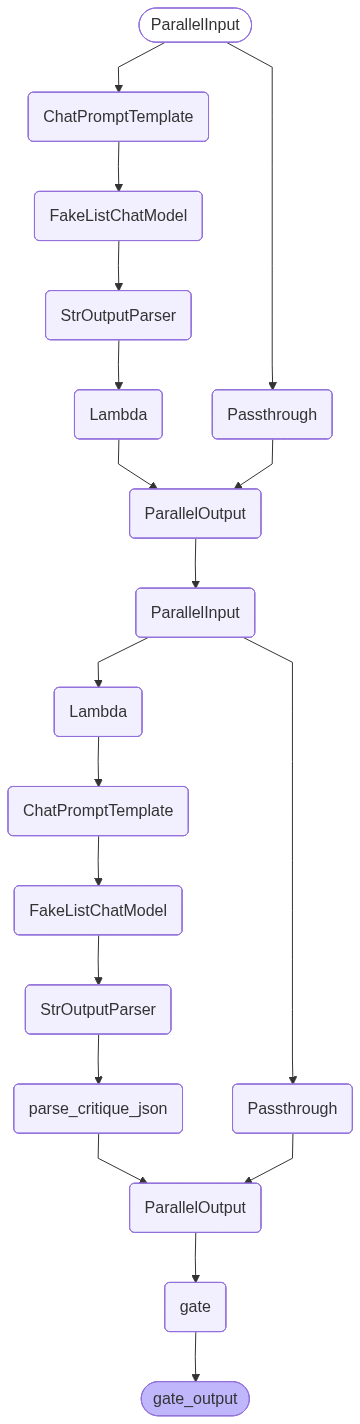

decision: accepted
trace: generated -> critiqued -> accepted
score: 0.9
issues: none
artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes.


In [4]:
# FakeListChatModel consumes one response per model call, in order:
# 1. generator -> INITIAL_DRAFT
# 2. critic -> GOOD_CRITIQUE_JSON
# This mirrors the live LCEL call sequence without requiring an API key.
accepted_model = FakeListChatModel(responses=[INITIAL_DRAFT, GOOD_CRITIQUE_JSON])
accepted_chain = build_chain(accepted_model, reviser=revise_with_evidence)
show_graph(accepted_chain, alt="Generator-Critic LCEL")
result = accepted_chain.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result)


## Mock run 2: blocker drafts a revision, but does not auto-accept

In [5]:
# Same generated draft, different critic evidence. The policy follows the
# critique object, so the blocker routes to revision instead of acceptance.
revision_model = FakeListChatModel(responses=[INITIAL_DRAFT, NEEDS_REVISION_CRITIQUE_JSON])
revision_chain = build_chain(revision_model, reviser=revise_with_evidence)
result = revision_chain.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result)


decision: needs_revision
trace: generated -> critiqued -> needs_revision -> revision_drafted
score: 0.74
issues: ['blocker:sentence 2:impact claim lacks a cited source']
artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.


## Mock run 3: malformed critic output fails closed

In [6]:
# The malformed critic response proves the parser fails closed: bad JSON becomes
# a blocker Critique, never an accidental pass.
parse_failure_model = FakeListChatModel(responses=[INITIAL_DRAFT, BAD_CRITIQUE_JSON])
parse_failure_chain = build_chain(parse_failure_model, reviser=revise_with_evidence)
result = parse_failure_chain.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result)


decision: needs_revision
trace: generated -> critiqued -> needs_revision -> revision_drafted
score: 0.0
issues: ['blocker:critic:critic output could not be parsed: JSONDecodeError: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)']
artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.


## Real backend

The same LCEL chain can use the configured model. Live calls are opt-in through `RUN_REAL_LLM=1` (or local lowercase `run_real_llm=1`) so a normal **Run All** stays deterministic and does not spend API credits.

In [7]:
# Keep the opt-in as a visible notebook variable. If this prints False, the
# real call is intentionally disabled before get_model() can touch the backend.
run_real_llm = run_real_llm_enabled()
model = get_model() if run_real_llm else None

if not run_real_llm:
    print("Skipping real backend run; set RUN_REAL_LLM=1 (or run_real_llm=1) and configure .env to enable it.")
elif model is None:
    print("Skipping real backend run; RUN_REAL_LLM is enabled but no configured model could be loaded.")
else:
    real_chain = build_chain(model)
    result = real_chain.invoke({"prompt": DEFAULT_PROMPT})
    print_trace(result)


Skipping real backend run; set RUN_REAL_LLM=1 (or run_real_llm=1) and configure .env to enable it.


## What to remember

- The critic returns evidence, not approval.
- The deterministic policy owns acceptance.
- Shared parsing makes both notebooks fail closed the same way.
- LCEL is compact, but the chain boundary is less visible than LangGraph.
- A revision draft still needs a fresh critique before it can be accepted.

## Further reading

- [LangGraph version](../langgraph/tutorial.ipynb)
- [Pattern README](../README.md)
- [Reference implementation guide](../../../REFERENCE_IMPL.md)
- [LangChain docs](https://docs.langchain.com/oss/python/langchain/overview)